Modeling workflow for the museum visitation forecasting portfolio project.  
This notebook trains and compares regression models using the prepared monthly feature table.

#1 Setup Environment, Import Libraries, and Setup Output Directories

In [116]:
# Import necessary libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, LassoLarsCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set up directories for outputs
BASE_DIR = Path("..")

PLOT_DIR = BASE_DIR / "outputs/plots"
TABLE_DIR = BASE_DIR / "outputs/tables"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

#2 Load the Dataset

In [117]:
# Load the processed dataset
DATA_PATH = Path("../data/processed/model_dataset.csv")
df = pd.read_csv(DATA_PATH)

# Convert 'month' column to datetime
df['month'] = pd.to_datetime(df['month'])

# Remove COVID closure months before preprocessing/modeling
df = df[~((df["month"] >= "2020-04-01") & (df["month"] <= "2021-05-01"))].copy()
df = df.reset_index(drop=True)

#3 Preprocessing

In [118]:
# Drop columns that are not relevant for modeling
cols_to_drop = [
    "mexican_heritage_los_angeles",
    "heritage_tourism_los_angeles",
    "historical_sites_los_angeles",
    "things_to_do_in_la_for_2_hours"
]

df = df.drop(columns=cols_to_drop)

time_cols_to_drop = [
    'month_num_x', 'month_num_y',
    'quarter',
    'school_year_month',
    'year_x', 'year_y'
]

df = df.drop(columns=[c for c in time_cols_to_drop if c in df.columns])

#4 Scaling and Cleaning

In [119]:
# Identify numeric columns and separate binary and continuous features
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop('visitors')

binary_cols = [c for c in num_cols if df[c].nunique() == 2]
cont_cols = num_cols.drop(binary_cols)

# Standardize continuous features using z-score normalization
df[cont_cols] = df[cont_cols].apply(stats.zscore)

# Handle infinite values and drop columns with all missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=1, how="all")

# Drop columns with low variance (constant features)
constant_cols = [
    c for c in df.columns
    if c not in ["visitors", "month"] and df[c].nunique(dropna=True) <= 1
]
df = df.drop(columns=constant_cols)

# Impute missing values in numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

#5 Data Summary

In [120]:
# Summary of the dataset
print(df.info())
print(df.describe())
print(df['visitors'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 63 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   month                                        64 non-null     datetime64[ns]
 1   visitors                                     64 non-null     int64         
 2   avg_temp_F                                   64 non-null     float64       
 3   min_temp_F                                   64 non-null     float64       
 4   max_temp_F                                   64 non-null     float64       
 5   total_precip_in                              64 non-null     float64       
 6   avg_wind_mph                                 64 non-null     float64       
 7   avila_adobe                                  64 non-null     float64       
 8   el_pueblo_los_angeles                        64 non-null     float64       
 9   g

#6 Train and Test Split

In [121]:
# Make sure data is sorted by time
df = df.sort_values("month").reset_index(drop=True)

# Define split index (80% train, 20% test)
split_index = int(len(df) * 0.80)

# Split the dataset (NO shuffling)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Define features (X) and target (y)
X_train = train.drop(columns=["visitors", "month"], errors="ignore")
y_train = train["visitors"]

X_test = test.drop(columns=["visitors", "month"], errors="ignore")
y_test = test["visitors"]

# Quick check
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train date range:", train["month"].min(), "to", train["month"].max())
print("Test date range:", test["month"].min(), "to", test["month"].max())

Train size: (51, 61)
Test size: (13, 61)
Train date range: 2015-01-01 00:00:00 to 2019-03-01 00:00:00
Test date range: 2019-04-01 00:00:00 to 2021-06-01 00:00:00


#7 Linear Regression

In [122]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lin_mae = mean_absolute_error(y_test, y_pred)
lin_r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression MAE:", lin_mae)
print("Linear Regression R2:", lin_r2)

Linear Regression RMSE: 8769.045381979693
Linear Regression MAE: 6205.8969669836815
Linear Regression R2: -0.8785940366027998


#8 OLS and Diagnostics

In [123]:
# OLS regression for interpretability
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               visitors   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                nan
Time:                        16:02:13   Log-Likelihood:                 1079.1
No. Observations:                  51   AIC:                            -2056.
Df Residuals:                       0   BIC:                            -1958.
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

<local_path_redacted>/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
<local_path_redacted>/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
<local_path_redacted>/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


#9 Correlation and VIF

In [124]:
# Check for multicollinearity using correlation matrix and VIF
print(df.corr()['visitors'].sort_values(ascending=False))

# Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df["Variable"] = X_train.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

# Display top 10 features with highest VIF
vif_df.sort_values("VIF", ascending=False).head(10)

visitors                          1.000000
visitors_lag12                    0.869475
los_angeles_attractions           0.815673
visitors_lag1                     0.691331
rolling_mean_3                    0.621479
                                    ...   
things_to_do_in_la_in_february   -0.422797
is_winter                        -0.435436
total_precip_in                  -0.451328
month_cos                        -0.502739
month                            -0.585836
Name: visitors, Length: 63, dtype: float64


<local_path_redacted>/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
<local_path_redacted>/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variable,VIF
0,avg_temp_F,inf
1,min_temp_F,inf
2,max_temp_F,inf
3,total_precip_in,inf
4,avg_wind_mph,inf
5,avila_adobe,inf
6,el_pueblo_los_angeles,inf
7,getty_museum,inf
8,griffith_observatory,inf
9,la_brea_tar_pits,inf


#10 Remove Outliers and Create Cleaned Dataset

In [125]:
# Identify outliers using studentized residuals
influence = ols_model.get_influence()
resid_student = influence.resid_studentized_external

# Typically, a common threshold for identifying outliers is an absolute studentized residual greater than 2 or 3
outlier_idx = np.where(np.abs(resid_student) > 2)[0]
print("Number of outliers detected:", len(outlier_idx))

# Remove outliers from the training set
train_outlier_index = X_train.index[outlier_idx]
df_clean = df.drop(index=train_outlier_index)

# Check how many rows were removed
df_clean = df_clean.sort_values("month").reset_index(drop=True)

# Redefine train/test split on the cleaned dataset
split_index_clean = int(len(df_clean) * 0.80)

# Create new train/test sets from the cleaned dataset
train_clean = df_clean.iloc[:split_index_clean]
test_clean = df_clean.iloc[split_index_clean:]

# Define features and target for the cleaned dataset
Xc_train = train_clean.drop(columns=["visitors", "month"], errors="ignore")
yc_train = train_clean["visitors"]

# Define features and target for the cleaned test set
Xc_test = test_clean.drop(columns=["visitors", "month"], errors="ignore")
yc_test = test_clean["visitors"]

# Final check on cleaned data
print("Cleaned train shape:", Xc_train.shape)
print("Cleaned test shape:", Xc_test.shape)

<local_path_redacted>/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
<local_path_redacted>/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Number of outliers detected: 0
Cleaned train shape: (51, 61)
Cleaned test shape: (13, 61)


<local_path_redacted>/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


#11 Cleaned Linear Regression

In [126]:
# Train linear regression on cleaned data
lin_clean = LinearRegression()
lin_clean.fit(Xc_train, yc_train)

# Predict and evaluate on the cleaned test set
y_pred_clean = lin_clean.predict(Xc_test)

# Evaluate the cleaned model
rmse_lin_clean = np.sqrt(mean_squared_error(yc_test, y_pred_clean))
clean_mae = mean_absolute_error(yc_test, y_pred_clean)
r2_lin_clean = r2_score(yc_test, y_pred_clean)

# Print cleaned model performance
print("Cleaned Linear Regression RMSE:", rmse_lin_clean)
print("Cleaned Linear Regression MAE:", clean_mae)
print("Cleaned Linear Regression R2:", r2_lin_clean)

Cleaned Linear Regression RMSE: 8769.045381979693
Cleaned Linear Regression MAE: 6205.8969669836815
Cleaned Linear Regression R2: -0.8785940366027998


#12 Reduced Model Using Average Temperature Only

In [127]:
# Reduce to a single predictor (avg_temp_F) for interpretability
X_clean = df_clean.drop(columns=["visitors", "month"], errors="ignore")
y_clean = df_clean["visitors"]

X_temp = X_clean[["avg_temp_F"]]

# Redefine train/test split for the single predictor model
split_index_temp = int(len(X_temp) * 0.80)

# Create new train/test sets for the single predictor model
X_tr = X_temp.iloc[:split_index_temp]
X_te = X_temp.iloc[split_index_temp:]

# Define target variable for the single predictor model
y_tr = y_clean.iloc[:split_index_temp]
y_te = y_clean.iloc[split_index_temp:]

# Train linear regression with single predictor
simple_reg = LinearRegression()
simple_reg.fit(X_tr, y_tr)

#
y_simple_pred = simple_reg.predict(X_te)

# Evaluate the single predictor model
print("Single Predictor RMSE:", np.sqrt(mean_squared_error(y_te, y_simple_pred)))
print("Single Predictor R2:", r2_score(y_te, y_simple_pred))

Single Predictor RMSE: 8379.596878411712
Single Predictor R2: -0.7154361451798734


#13 Lasso Model

In [128]:
# Train LASSO regression with cross-validation to find optimal alpha
lasso_cv = LassoCV(
    cv=10,
    n_alphas=100,
    random_state=1234
)

lasso_cv.fit(Xc_train, yc_train)

# Predict on the test set using the best alpha
y_pred_lasso = lasso_cv.predict(Xc_test)

# Evaluate the LASSO model
lasso_rmse = np.sqrt(mean_squared_error(yc_test, y_pred_lasso))
lasso_mae = mean_absolute_error(yc_test, y_pred_lasso)
lasso_r2 = r2_score(yc_test, y_pred_lasso)

# Print LASSO performance and selected alpha
print("LASSO RMSE:", lasso_rmse)
print("LASSO MAE:", lasso_mae)
print("LASSO R2:", lasso_r2)
print("Selected alpha:", lasso_cv.alpha_)

<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.443e+05, tolerance: 1.235e+05
  model = cd_fast.enet_coordinate_descent(
<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterati

LASSO RMSE: 2986.710830838138
LASSO MAE: 2258.0568780832514
LASSO R2: 0.7820711847974954
Selected alpha: 325.0771089840331


#14 Plot 1: LASSO Coefficient Paths and Cross-Validation Error

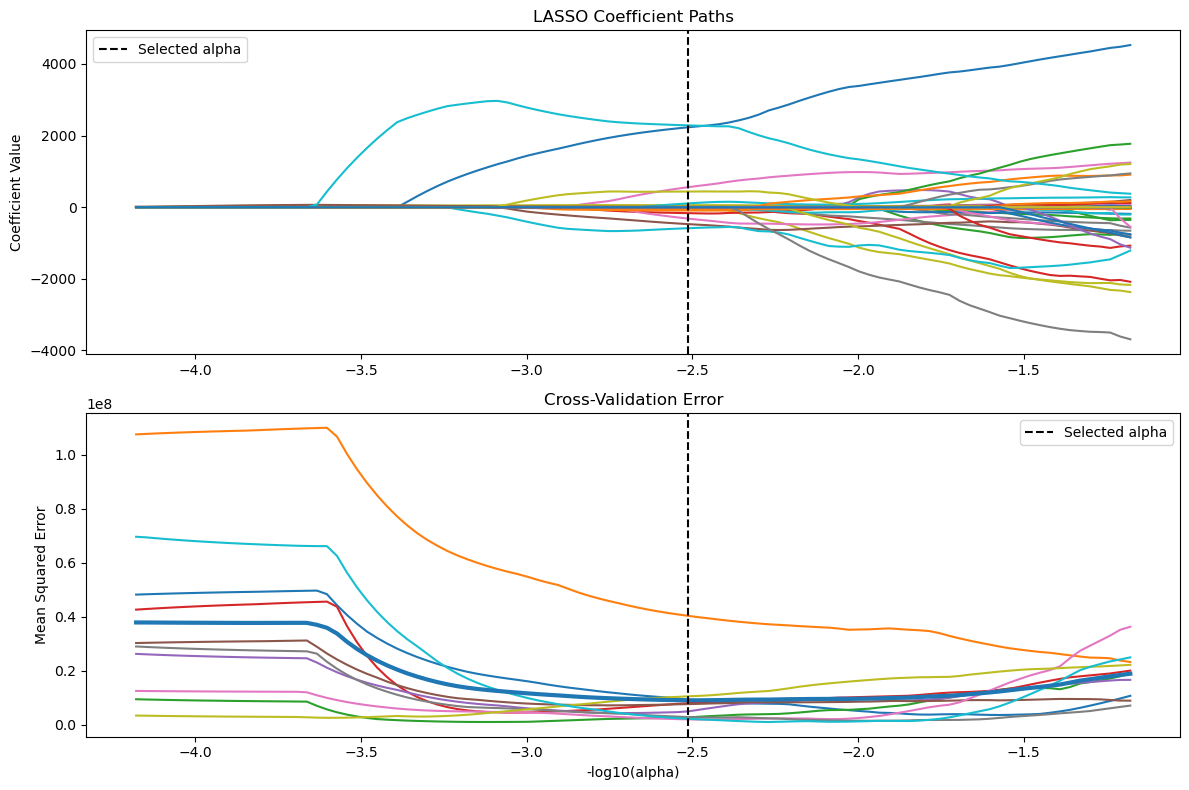

In [129]:
# Visualize LASSO coefficient paths and cross-validation error
alphas = lasso_cv.alphas_
coef_path = []

# Fit LASSO for each alpha to get coefficient paths
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(Xc_train, yc_train)
    coef_path.append(lasso.coef_)

coef_path = np.array(coef_path)

# Convert alphas to log scale for better visualization
log_alphas = -np.log10(alphas)
log_alpha_star = -np.log10(lasso_cv.alpha_)

# Create subplots for coefficient paths and cross-validation error
plt.figure(figsize=(12, 8))

# Plot coefficient paths
plt.subplot(2, 1, 1)
plt.plot(log_alphas, coef_path)
plt.axvline(log_alpha_star, linestyle="--", color="black", label="Selected alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.legend(loc="best")

# Plot cross-validation error
plt.subplot(2, 1, 2)
plt.plot(log_alphas, lasso_cv.mse_path_)
plt.plot(log_alphas, lasso_cv.mse_path_.mean(axis=1), linewidth=3)
plt.axvline(log_alpha_star, linestyle="--", color="black", label="Selected alpha")
plt.xlabel("-log10(alpha)")
plt.ylabel("Mean Squared Error")
plt.title("Cross-Validation Error")
plt.legend(loc="best")

plt.tight_layout()
plt.savefig(PLOT_DIR / "lasso_coef_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#15 Plot 2: LASSO Top Predictors

--- Non-Zero LASSO Predictors ---
visitors_lag12                                 2285.336107
los_angeles_attractions                        2233.530103
month_cos                                      -585.772791
el_pueblo_los_angeles                           561.057692
things_to_do_in_la_in_february                 -472.445516
visitors_lag1                                   438.261413
living_history_museum                          -318.278850
indoor_things_to_do_in_los_angeles             -165.848526
historic_district_los_angeles                   106.666387
rainy_day_activities_los_angeles                -91.894894
historic_attractions_los_angeles                 58.156062
things_to_do_near_union_station_los_angeles     -51.288719
interactive_museums_los_angeles                 -34.511514
things_to_do_in_la_for_a_couple_hours           -23.085869
oldest_house_los_angeles                        -15.781042
family_things_to_do_in_downtown_la                8.740828
kid_friendly_museums_l

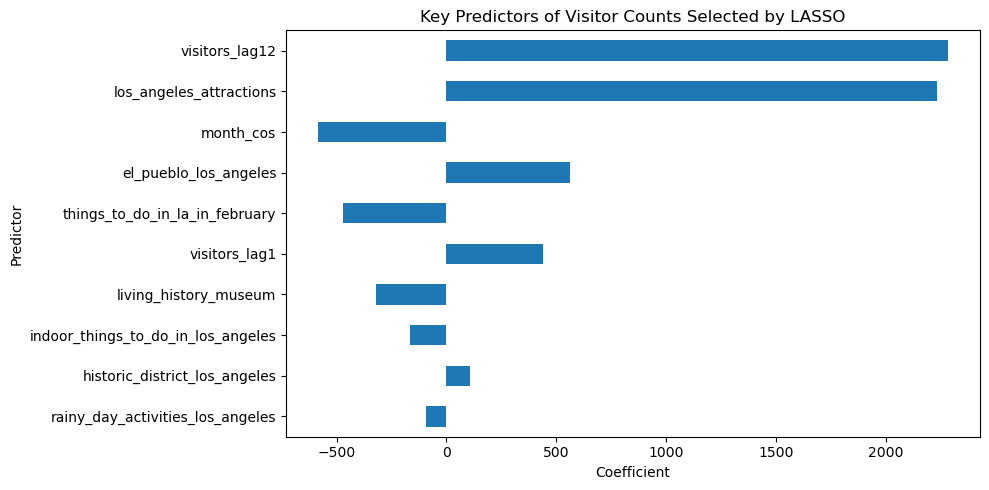

In [130]:
# Extract non-zero coefficients from the LASSO model
lasso_coef = pd.Series(
    lasso_cv.coef_,
    index=Xc_train.columns
)

# Filter to non-zero coefficients and sort by absolute value
lasso_coef = lasso_coef[np.abs(lasso_coef) > 1e-4].sort_values(key=np.abs, ascending=False)

# Print non-zero LASSO predictors and visualize the top ones
print("--- Non-Zero LASSO Predictors ---")
print(lasso_coef)

# Visualize the top 10 predictors selected by LASSO
lasso_coef.head(10).plot(
    kind="barh",
    figsize=(10, 5),
    title="Key Predictors of Visitor Counts Selected by LASSO"
)

# Invert y-axis to have the most important predictor at the top
plt.gca().invert_yaxis()
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig(PLOT_DIR / "lasso_top_predictors_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#16 Predictor Stability Across Folds

In [131]:
# Assess predictor stability across folds in LASSO
kf = KFold(n_splits=10, shuffle=False)

# Count how many times each predictor is selected (non-zero coefficient) across the folds
selected_counts = pd.Series(0, index=Xc_train.columns)

# Fit LASSO on each fold and count non-zero coefficients
for train_idx, test_idx in kf.split(Xc_train):
    lasso_tmp = Lasso(alpha=lasso_cv.alpha_)
    lasso_tmp.fit(
        Xc_train.iloc[train_idx],
        yc_train.iloc[train_idx]
    )
    selected_counts += (lasso_tmp.coef_ != 0).astype(int)

# Sort predictors by how many times they were selected across folds
selected_counts = selected_counts.sort_values(ascending=False)

# Print predictors that were selected in at least one fold
print("--- Predictor Stability Across Folds ---")
print(selected_counts[selected_counts > 0])

--- Predictor Stability Across Folds ---
el_pueblo_los_angeles                          10
los_angeles_attractions                        10
visitors_lag12                                 10
visitors_lag1                                  10
things_to_do_in_la_in_february                 10
month_cos                                      10
living_history_museum                           9
oldest_house_los_angeles                        9
things_to_do_in_la_for_a_couple_hours           9
interactive_museums_los_angeles                 9
indoor_things_to_do_in_los_angeles              9
historic_attractions_los_angeles                9
family_things_to_do_in_downtown_la              9
things_to_do_near_union_station_los_angeles     9
rainy_day_activities_los_angeles                8
historic_district_los_angeles                   8
kid_friendly_museums_los_angeles                7
oldest_home_in_los_angeles                      6
total_precip_in                                 2
things_to

#17 Plot 3: LASSO Residuals Over Time

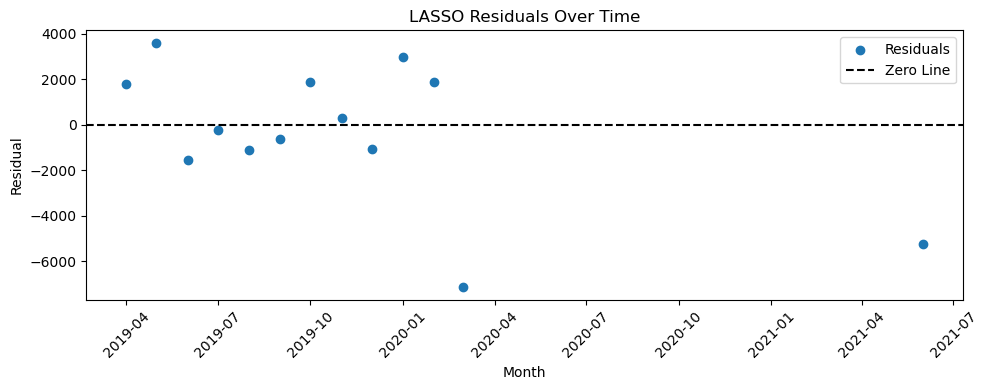

In [132]:
# Analyze residuals of the LASSO model to check for patterns over time
residuals = yc_test - y_pred_lasso

# Visualize residuals over time to check for any patterns or trends
plt.figure(figsize=(10, 4))
plt.scatter(test_clean["month"], residuals, label="Residuals")
plt.axhline(0, color="black", linestyle="--", label="Zero Line")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Residual")
plt.title("LASSO Residuals Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / "lasso_residuals_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

#18 Plot 4: Actual vs Predicted Visitors

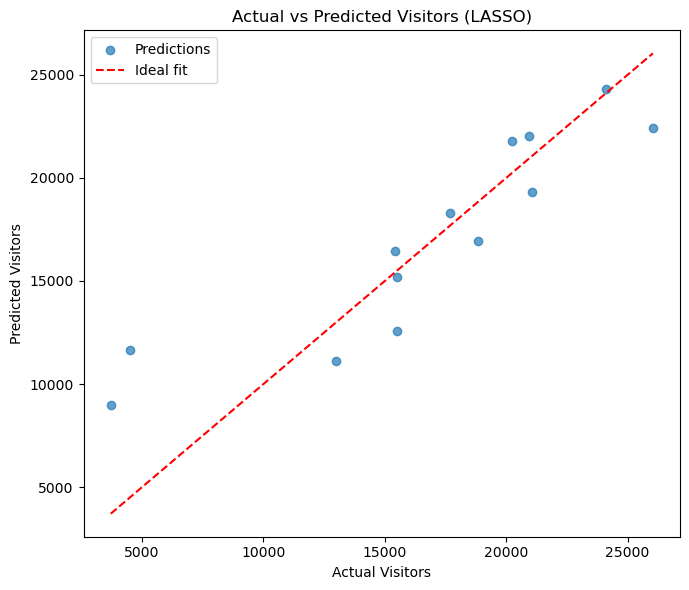

In [133]:
# Visualize actual vs predicted values for the LASSO model
plt.figure(figsize=(7, 6))
plt.scatter(yc_test, y_pred_lasso, alpha=0.7, label="Predictions")
plt.plot(
    [yc_test.min(), yc_test.max()],
    [yc_test.min(), yc_test.max()],
    "r--",
    label="Ideal fit"
)

plt.xlabel("Actual Visitors")
plt.ylabel("Predicted Visitors")
plt.title("Actual vs Predicted Visitors (LASSO)")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "lasso_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

#19 LASSO-LARS Model

In [134]:
# Train LASSO-LARS regression with cross-validation to find optimal alpha
lasso_lars = LassoLarsCV(cv=10)
lasso_lars.fit(Xc_train, yc_train)

# Predict on the test set using the best alpha from LASSO-LARS
y_pred_lars = lasso_lars.predict(Xc_test)

# Evaluate the LASSO-LARS model
rmse_lars = np.sqrt(mean_squared_error(yc_test, y_pred_lars))
lasso_lars_mae = mean_absolute_error(yc_test, y_pred_lars)
lasso_lars_r2 = r2_score(yc_test, y_pred_lars)

# Print LASSO-LARS performance and selected alpha
print("LASSO-LARS RMSE:", rmse_lars)
print("LASSO-LARS MAE:", lasso_lars_mae)
print("LASSO-LARS R2:", lasso_lars_r2)
print("Selected alpha:", lasso_lars.alpha_)

LASSO-LARS RMSE: 2982.0439278054
LASSO-LARS MAE: 2259.141474213175
LASSO-LARS R2: 0.7827517046772372
Selected alpha: 320.7793059579744


<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 60 iterations, i.e. alpha=3.990e+01, with an active set of 34 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 62 iterations, i.e. alpha=3.738e+01, with an active set of 36 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
<local_path_redacted>/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 64 iterations, alpha=3.411e+01

#20 Plot 5: LASSO-LARS Coefficient Paths

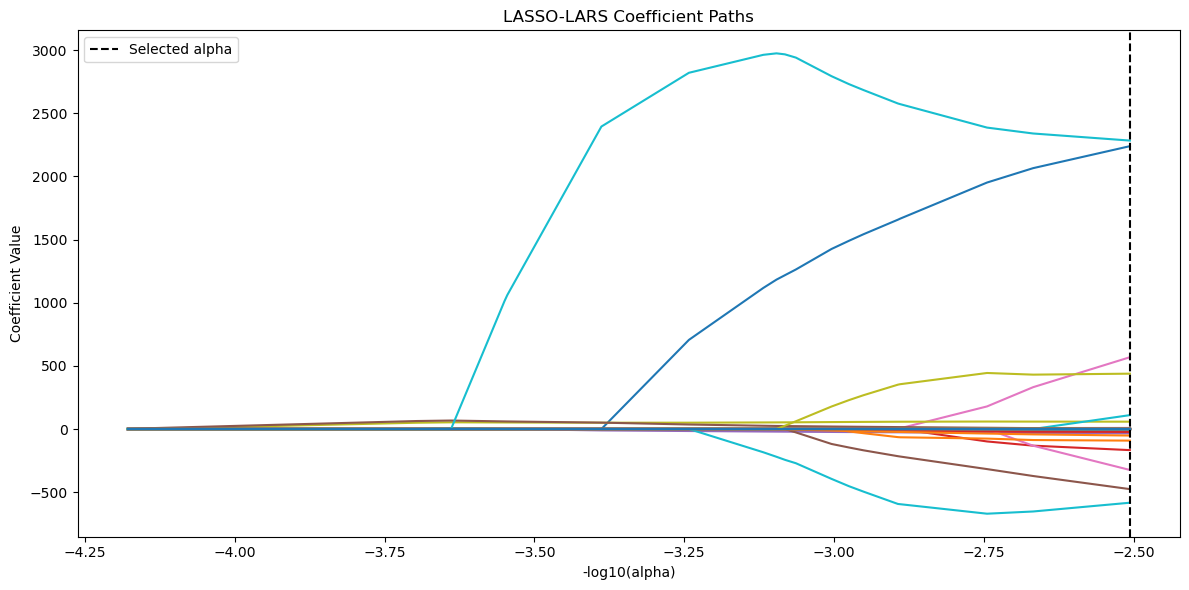

In [135]:
# Visualize LASSO-LARS coefficient paths
alphas_lars = lasso_lars.alphas_
coef_path_lars = lasso_lars.coef_path_.T

# Convert alphas to log scale for better visualization
log_alphas_lars = -np.log10(alphas_lars)
log_alpha_star_lars = -np.log10(lasso_lars.alpha_)

# Create plot for LASSO-LARS coefficient paths
plt.figure(figsize=(12, 6))

for i in range(coef_path_lars.shape[1]):
    plt.plot(log_alphas_lars, coef_path_lars[:, i])

plt.axvline(
    log_alpha_star_lars,
    linestyle="--",
    color="black",
    label="Selected alpha"
)

plt.xlabel("-log10(alpha)")
plt.ylabel("Coefficient Value")
plt.title("LASSO-LARS Coefficient Paths")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(PLOT_DIR / "lasso_lars_coef_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#21 Random Forest Model

In [136]:
# Train Random Forest regression on the cleaned dataset
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=1234,
    max_depth=5
)

# Fit the Random Forest model on the cleaned training data
rf_model.fit(Xc_train, yc_train)

# Predict on the test set using the Random Forest model
y_pred_rf = rf_model.predict(Xc_test)

# predict on the test set using the original features (not cleaned) for comparison
rf_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_rmse = np.sqrt(mean_squared_error(yc_test, y_pred_rf))
rf_mae = mean_absolute_error(yc_test, y_pred_rf)
rf_r2 = r2_score(yc_test, y_pred_rf)

# Print Random Forest performance
print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 5533.447993828207
Random Forest MAE: 3604.1399360539936
Random Forest R2: 0.25196835773928994


#22 Random Forest Feature Importance

In [137]:
# Extract feature importance from the Random Forest model
rf_importance = pd.DataFrame({
    "feature": Xc_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

# Save Random Forest feature importance to CSV
rf_importance.to_csv(TABLE_DIR / "random_forest_feature_importance.csv", index=False)

# Display the top 15 most important features according to the Random Forest model
rf_importance.head(15)

,feature,importance
59,visitors_lag12,0.661696
10,los_angeles_attractions,0.070752
1,min_temp_F,0.038817
35,things_to_do_in_la_in_february,0.030393
3,total_precip_in,0.029122
49,month_cos,0.022436
13,olvera_street,0.018233
15,family_activities_los_angeles,0.014903
60,rolling_mean_3,0.014832
0,avg_temp_F,0.013123


#23 Plot 6 Random Forest Feature Importance

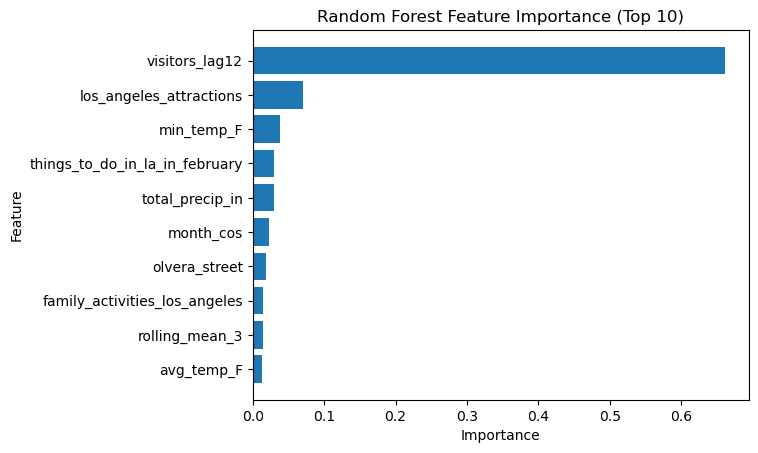

In [138]:
fi = pd.read_csv(TABLE_DIR / "random_forest_feature_importance.csv")

# Top 10 features
fi = fi.sort_values(by="importance", ascending=False).head(10)

plt.figure()
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(PLOT_DIR / "rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

#24 Plot 7 Random Forest Actual vs Predicted Visitors

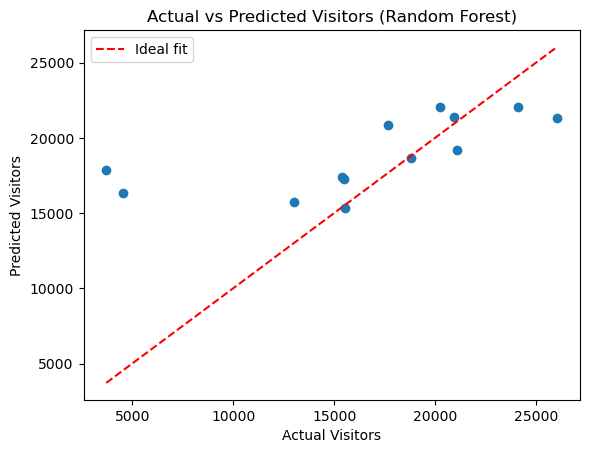

In [139]:
plt.figure()
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Ideal fit")

plt.title("Actual vs Predicted Visitors (Random Forest)")
plt.xlabel("Actual Visitors")
plt.ylabel("Predicted Visitors")
plt.legend()

plt.savefig(PLOT_DIR / "rf_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

#25 Plot 8 Random Forest Residuals Over Time

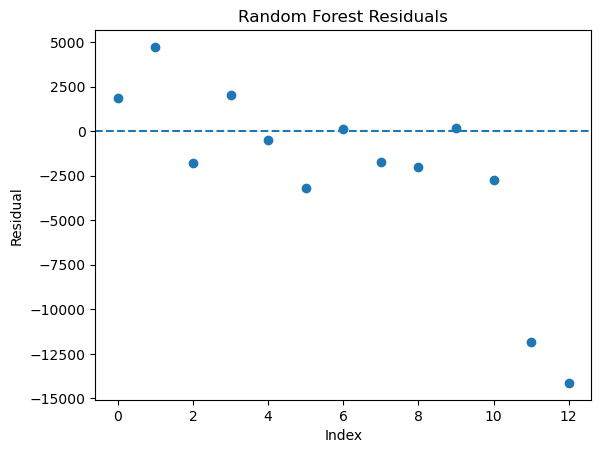

In [140]:
residuals = y_test - rf_pred

plt.figure()
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, linestyle="--")

plt.title("Random Forest Residuals")
plt.xlabel("Index")
plt.ylabel("Residual")

plt.savefig(PLOT_DIR / "rf_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

#26 Gradient Boosting Model

In [141]:
# Train Gradient Boosting regression on the cleaned dataset
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=1234
)

# Fit the Gradient Boosting model on the cleaned training data
gb_model.fit(Xc_train, yc_train)

# Predict on the test set using the Gradient Boosting model
y_pred_gb = gb_model.predict(Xc_test)

# Evaluate the Gradient Boosting model
gb_rmse = np.sqrt(mean_squared_error(yc_test, y_pred_gb))
gb_mae = mean_absolute_error(yc_test, y_pred_gb)
gb_r2 = r2_score(yc_test, y_pred_gb)

# Print Gradient Boosting performance
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting RMSE: 5001.671409559991
Gradient Boosting MAE: 3340.3230544619164
Gradient Boosting R2: 0.3888347994073391


#27 Plot 9 Gradient Boosting Feature Importance

                           feature  importance
59                  visitors_lag12    0.771721
10         los_angeles_attractions    0.035112
1                       min_temp_F    0.033111
3                  total_precip_in    0.029210
13                   olvera_street    0.021838
40     things_to_do_in_downtown_la    0.016882
35  things_to_do_in_la_in_february    0.015930
0                       avg_temp_F    0.013073
15   family_activities_los_angeles    0.010709
60                  rolling_mean_3    0.009927


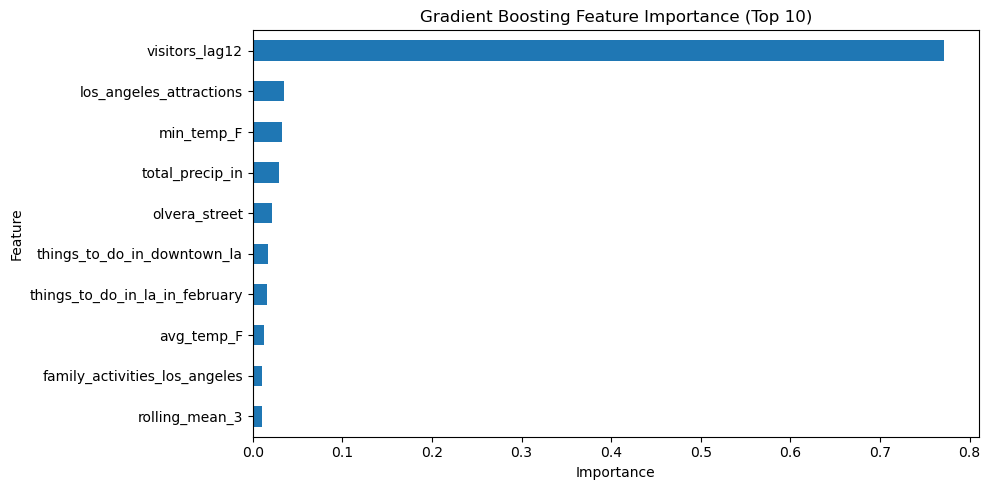

In [142]:
# Gradient Boosting Feature Importance

gb_importance = pd.DataFrame({
    "feature": Xc_train.columns,
    "importance": gb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(gb_importance.head(10))

gb_importance.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 5),
    legend=False,
    title="Gradient Boosting Feature Importance (Top 10)"
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(PLOT_DIR / "gb_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

#28 Plot 10 Gradient Boosting Actual vs Predicted Visitors

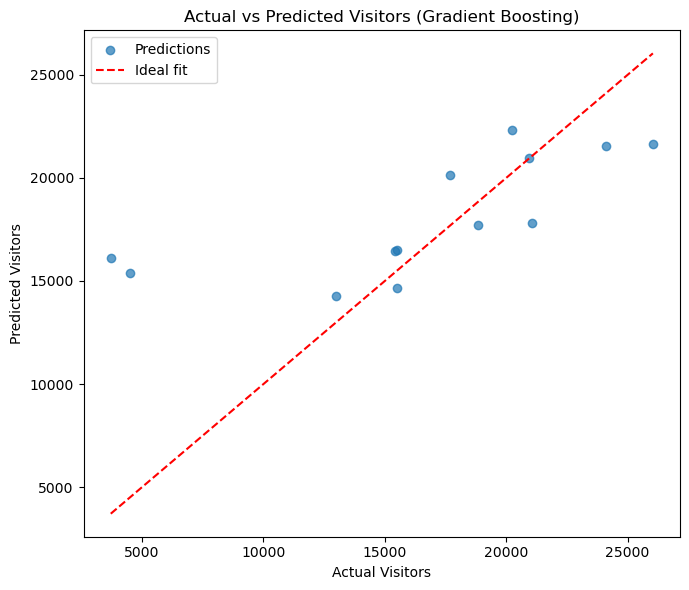

In [143]:
# Gradient Boosting Actual vs Predicted Plot

plt.figure(figsize=(7, 6))
plt.scatter(yc_test, y_pred_gb, alpha=0.7, label="Predictions")
plt.plot(
    [yc_test.min(), yc_test.max()],
    [yc_test.min(), yc_test.max()],
    "r--",
    label="Ideal fit"
)

plt.title("Actual vs Predicted Visitors (Gradient Boosting)")
plt.xlabel("Actual Visitors")
plt.ylabel("Predicted Visitors")
plt.legend()
plt.tight_layout()

plt.savefig(PLOT_DIR / "gb_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

#29 Plot 11 Gradient Residual Residuals Over Time

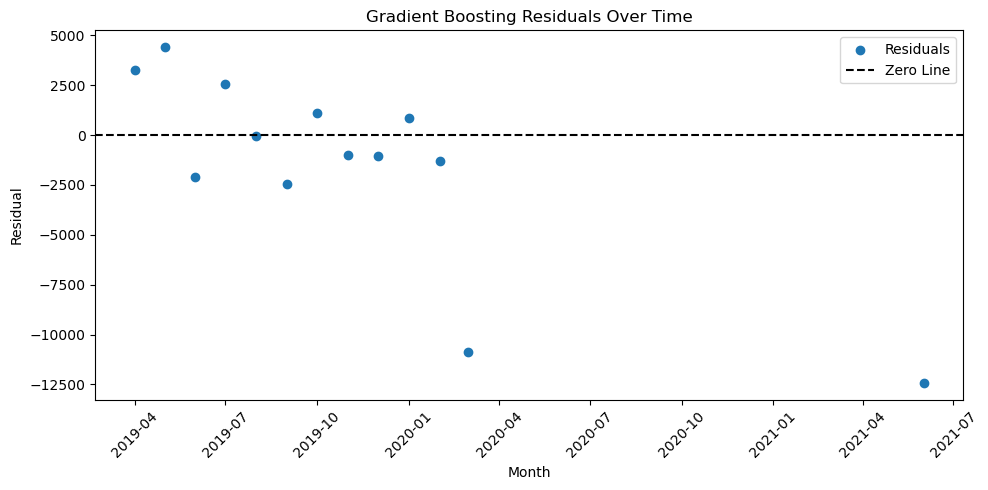

In [144]:
# Gradient Boosting Residual Plot

gb_residuals = yc_test - y_pred_gb

plt.figure(figsize=(10, 5))
plt.scatter(test_clean["month"], gb_residuals, label="Residuals")
plt.axhline(0, color="black", linestyle="--", label="Zero Line")

plt.title("Gradient Boosting Residuals Over Time")
plt.xlabel("Month")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(PLOT_DIR / "gb_residuals_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

#30 Model Comparison Table

In [145]:
# Create a comparison table of all models
comparison_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Cleaned Linear Regression",
        "LASSO",
        "LASSO-LARS",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        lin_rmse,
        rmse_lin_clean,
        lasso_rmse,
        rmse_lars,
        rf_rmse,
        gb_rmse
    ],
    "MAE": [
        lin_mae,
        clean_mae,
        lasso_mae,
        lasso_lars_mae,
        rf_mae,
        gb_mae
    ],
    "R2": [
        lin_r2,
        r2_lin_clean,
        lasso_r2,
        lasso_lars_r2,
        rf_r2,
        gb_r2
    ]
})

# Round the comparison table to 3 decimal places for better readability
comparison_table = comparison_table.round(3)

# Save the model comparison table to CSV
comparison_table.to_csv(TABLE_DIR / "model_comparison_table.csv", index=False)

# Display the model comparison table
comparison_table

,Model,RMSE,MAE,R2
0,Linear Regression,8769.045,6205.897,-0.879
1,Cleaned Linear Regression,8769.045,6205.897,-0.879
2,LASSO,2986.711,2258.057,0.782
3,LASSO-LARS,2982.044,2259.141,0.783
4,Random Forest,5533.448,3604.140,0.252
5,Gradient Boosting,5001.671,3340.323,0.389


#31 Final Notes

In [146]:
# Identify the best model based on RMSE
best_model = comparison_table.sort_values("RMSE").iloc[0]

# Print the best model and main interpretation of results
print("Best model based on RMSE:")
print(best_model)

print("\nMain interpretation:")
print("LASSO and LASSO-LARS are strong because they reduce overfitting and handle correlated predictors.")
print("Lag features, especially visitors_lag1 and visitors_lag12, are among the most important predictors.")
print("Weather and seasonality contribute, but past visitation and Google Trends variables are the strongest signals.")

Best model based on RMSE:
Model    LASSO-LARS
RMSE       2982.044
MAE        2259.141
R2            0.783
Name: 3, dtype: object

Main interpretation:
LASSO and LASSO-LARS are strong because they reduce overfitting and handle correlated predictors.
Lag features, especially visitors_lag1 and visitors_lag12, are among the most important predictors.
Weather and seasonality contribute, but past visitation and Google Trends variables are the strongest signals.
